In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

%matplotlib widget

In [45]:
c = 3e8  # speed of light in m/s

In [46]:
Y = np.array([0, 0, 500e3])
Yv = np.array([1, 1, 0])

X = 100e3 * np.array([[0, 0, 0],
              [1, 1, 0],
              [1, -1, 0],
              [1, 0, 0]])

print("target Y:", Y)
print("target Yv:", Yv)
print("sensors X:", *X)

target Y: [     0.      0. 500000.]
target Yv: [1 1 0]
sensors X: [0. 0. 0.] [100000. 100000.      0.] [ 100000. -100000.       0.] [100000.      0.      0.]


In [47]:
Ryi = np.linalg.norm(X - Y, axis=1)
tau_yi = Ryi / c

print("distances Ryi:", *Ryi)
print("time differences tauyi:", *tau_yi)

distances Ryi: 500000.0 519615.2422706632 519615.2422706632 509901.95135927846
time differences tauyi: 0.0016666666666666668 0.0017320508075688774 0.0017320508075688774 0.0016996731711975948


In [48]:
tau_ij = (tau_yi[:, np.newaxis] - tau_yi[np.newaxis, :])
tau_ij

array([[ 0.00000000e+00, -6.53841409e-05, -6.53841409e-05,
        -3.30065045e-05],
       [ 6.53841409e-05,  0.00000000e+00,  0.00000000e+00,
         3.23776364e-05],
       [ 6.53841409e-05,  0.00000000e+00,  0.00000000e+00,
         3.23776364e-05],
       [ 3.30065045e-05, -3.23776364e-05, -3.23776364e-05,
         0.00000000e+00]])

In [49]:
def solve_tdoa(tau_ij, X):
  """ 
  Solve for the position of the target using TDOA measurements.
  
  Parameters:
  tau_ij : np.ndarray
      The time difference of arrival (TDOA) measurements between sensors.
  X : np.ndarray
      The positions of the sensors.
      
  Returns:
  np.ndarray
      The estimated position of the target.
  """
  
  Y_guess = np.random.rand(3) * 1e6  # Initial guess for the target position
  
  def objective_function(Y):
    Ryi = np.linalg.norm(X - Y, axis=1)
    tau_ij_estimated = (Ryi[:, np.newaxis] - Ryi[np.newaxis, :]) / c
    return np.mean((tau_ij_estimated - tau_ij) ** 2) * 1e9
  
  minimization_result = minimize(objective_function, Y_guess, method='Nelder-Mead', tol=1e-12, options={'maxiter': 1000})
  
  return minimization_result.x

In [52]:
noise_scales = np.logspace(-6, -9, 4)  # Varying noise scales for Monte Carlo simulation

monte_carlo_results = {}  # Dictionary to store results for each noise scale
monte_carlo_runs = 100

for noise_scale in noise_scales:
  
  monte_carlo_input = np.empty((monte_carlo_runs, 4))  # Store results of each run
  monte_carlo_result = np.empty((monte_carlo_runs, 3))  # Store results of each run
  
  for run in range(monte_carlo_runs):
    tau_yi_noise = np.random.normal(tau_yi, noise_scale)  # Add noise to the TDOA measurements
    tau_ij_noise = (tau_yi_noise[:, np.newaxis] - tau_yi_noise[np.newaxis, :])  # Recalculate TDOA with noise


    try:
      solved_position = solve_tdoa(tau_ij_noise, X)
      if np.linalg.norm(solved_position - Y) > 1e6:  # Check if the solution is reasonable
          raise ValueError("Estimated position is too far from the true position.")
      monte_carlo_result[run] = solved_position
      monte_carlo_input[run] = tau_yi_noise
      # print("Estimated target position:", solved_position)
      # print("True target position:", Y)
      # print(f"Noise scale: {noise_scale:.2e}, Estimated position: {solved_position}, True position: {Y}, Error: {np.linalg.norm(solved_position - Y):.2f} m")
    except Exception as e:
      print("Error occurred while solving TDOA:", e)
      monte_carlo_result[run] = np.nan  # Store NaN for failed runs
  
  monte_carlo_results[noise_scale] = {
    "input": monte_carlo_input,
    "result": monte_carlo_result
  }


Error occurred while solving TDOA: Estimated position is too far from the true position.
Error occurred while solving TDOA: Estimated position is too far from the true position.
Error occurred while solving TDOA: Estimated position is too far from the true position.
Error occurred while solving TDOA: Estimated position is too far from the true position.


Noise scale: 1.00e-06, Mean error: 15542.36 m, Std error: 10674.10 m
Noise scale: 1.00e-07, Mean error: 1668.41 m, Std error: 1125.49 m
Noise scale: 1.00e-08, Mean error: 162.05 m, Std error: 107.66 m
Noise scale: 1.00e-09, Mean error: 16.68 m, Std error: 12.80 m


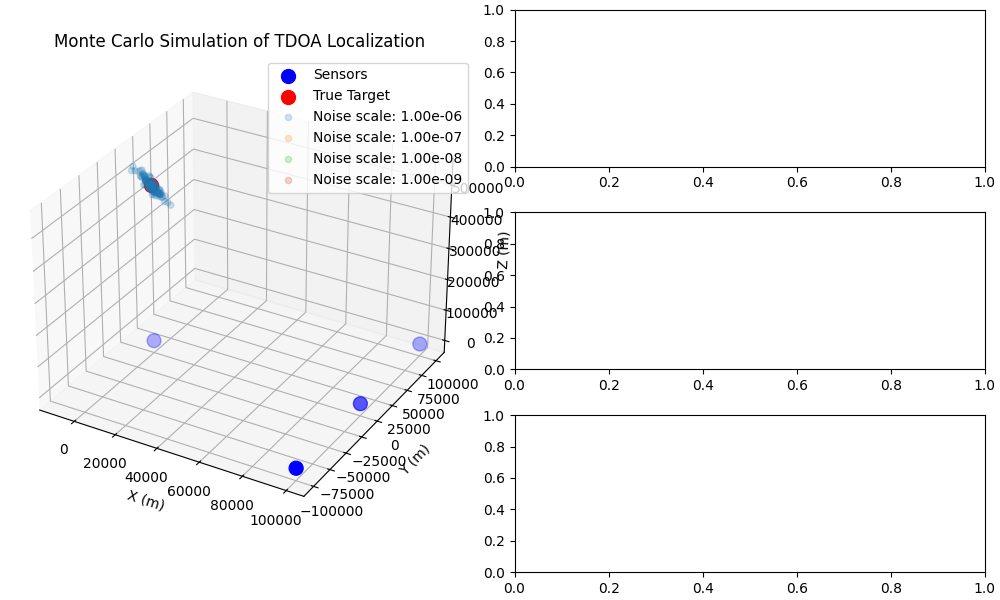

In [53]:

fig = plt.figure(figsize=(10, 6), constrained_layout=True)
ax_3d = fig.add_subplot(3, 4, (1, 10), projection='3d')
ax_x = fig.add_subplot(3, 4, (3, 4))
ax_y = fig.add_subplot(3, 4, (7, 8))
ax_z = fig.add_subplot(3, 4, (11, 12))
ax_3d.scatter(X[:, 0], X[:, 1], X[:, 2], c='blue', label='Sensors', s=100)
ax_3d.scatter(Y[0], Y[1], Y[2], c='red', label='True Target', s=100)

for noise_scale, results in monte_carlo_results.items():
    result = results["result"]
    tau_yi_noisy = results["input"]
    
    
    errors = np.linalg.norm(result - Y, axis=1)  # Calculate errors for each run
    mean_error = np.nanmean(errors)  # Mean error, ignoring NaN values
    std_error = np.nanstd(errors)  # Standard deviation of errors, ignoring NaN values
    
    ax_3d.scatter(result[:, 0], result[:, 1], result[:, 2], label=f'Noise scale: {noise_scale:.2e}', alpha=0.2)
    
    print(f"Noise scale: {noise_scale:.2e}, Mean error: {mean_error:.2f} m, Std error: {std_error:.2f} m")
    
ax_3d.set_xlabel('X (m)')
ax_3d.set_ylabel('Y (m)')
ax_3d.set_zlabel('Z (m)')
ax_3d.set_title('Monte Carlo Simulation of TDOA Localization')
ax_3d.legend()